In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis


# Semente para os resultados serem reproduzíveis
np.random.seed(42)

In [8]:
# ============================================================
# Valores teóricos
# ============================================================

teoricos_uniforme = {
    "Média": 1.5,
    "Mediana": 1.5,
    "Moda estimada": np.nan,   # Uniforme não possui moda única
    "Variância": 6.75,
    "Assimetria": 0,
    "Curtose": -1.2
}

teoricos_normal = {
    "Média": 3,
    "Mediana": 3,
    "Moda estimada": 3,
    "Variância": 4,
    "Assimetria": 0,
    "Curtose": 0
}

# ============================================================
# Função para estimar a moda de uma variável contínua
# ============================================================

def moda_histograma(x, bins=30):
    """
    Estima a moda usando o intervalo mais frequente do histograma.

    Retorna o ponto médio do intervalo com maior frequência.
    """

    frequencias, bordas = np.histogram(x, bins=bins)

    indice_maior = np.argmax(frequencias)

    limite_inferior = bordas[indice_maior]
    limite_superior = bordas[indice_maior + 1]

    moda = (limite_inferior + limite_superior) / 2

    return moda


# ============================================================
# Função para calcular as estatísticas
# ============================================================

def calcular_estatisticas(x, bins_moda=30):

    return {
        "Média": np.mean(x),
        "Mediana": np.median(x),
        "Moda estimada": moda_histograma(x, bins=bins_moda),

        # ddof=1 -> variância amostral
        "Variância": np.var(x, ddof=1),

        "Assimetria": skew(x, bias=False),

        # fisher=True:
        # normal -> curtose excedente = 0
        "Curtose": kurtosis(
            x,
            fisher=True,
            bias=False
        )
    }

def comparar_com_teorico(estatisticas, teoricos):
    comparacao = []

    for medida, valor_amostral in estatisticas.items():
        valor_teorico = teoricos[medida]

        # Caso especial: não existe valor teórico único
        if np.isnan(valor_teorico):
            erro_absoluto = np.nan
            erro_relativo = np.nan
        else:
            erro_absoluto = abs(valor_amostral - valor_teorico)

            # Evita divisão por zero
            if valor_teorico != 0:
                erro_relativo = (
                    erro_absoluto / abs(valor_teorico)
                ) * 100
            else:
                erro_relativo = np.nan

        comparacao.append({
            "Estatística": medida,
            "Amostral": valor_amostral,
            "Teórico": valor_teorico,
            "Erro absoluto": erro_absoluto,
            "Erro relativo (%)": erro_relativo
        })

    return pd.DataFrame(comparacao)

In [9]:
# ============================================================
# Generate random variables
# ============================================================

def generate_random_variables(n=1000, return_samples=False):
    resultados = []

    # --------------------------------------------------------
    # Distribuição uniforme
    # --------------------------------------------------------

    xU = np.random.uniform(
        low=-3,
        high=6,
        size=n
    )

    # --------------------------------------------------------
    # Distribuição normal
    # --------------------------------------------------------

    xN = np.random.normal(
        loc=3,       # média
        scale=2,     # desvio padrão
        size=n
    )

    # --------------------------------------------------------
    # Estatísticas
    # --------------------------------------------------------

    estat_U = calcular_estatisticas(xU)
    estat_N = calcular_estatisticas(xN)

    comparacao_U = comparar_com_teorico(
        estat_U,
        teoricos_uniforme
    )

    comparacao_N = comparar_com_teorico(
        estat_N,
        teoricos_normal
    )

    resultados.append({
        "N": n,
        "Distribuição": "Uniforme",
        **estat_U
    })

    resultados.append({
        "N": n,
        "Distribuição": "Normal",
        **estat_N
    })

    print("\n===================================")
    print(f"Distribuição Uniforme - N = {n}")
    print("===================================")
    print(comparacao_U.round(4))

    print("\n===================================")
    print(f"Distribuição Normal - N = {n}")
    print("===================================")
    print(comparacao_N.round(4))

    # ========================================================
    # Gráficos
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8)
    )

    # --------------------------------------------------------
    # Histograma uniforme
    # --------------------------------------------------------

    axes[0, 0].hist(
        xU,
        bins=30,
        edgecolor="black",
        density=True
    )

    axes[0, 0].set_title(
        f"Histograma - Uniforme U(-3, 6) - N = {n:,}"
    )

    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("Densidade")

    # --------------------------------------------------------
    # Boxplot uniforme
    # --------------------------------------------------------

    axes[1, 0].boxplot(
        xU,
        vert=False
    )

    axes[1, 0].set_title(
        f"Boxplot - Uniforme - N = {n:,}"
    )

    axes[1, 0].set_xlabel("x")

    # --------------------------------------------------------
    # Histograma normal
    # --------------------------------------------------------

    axes[0, 1].hist(
        xN,
        bins=30,
        edgecolor="black",
        density=True
    )

    axes[0, 1].set_title(
        f"Histograma - Normal N(3, 2²) - N = {n:,}"
    )

    axes[0, 1].set_xlabel("x")
    axes[0, 1].set_ylabel("Densidade")

    # --------------------------------------------------------
    # Boxplot normal
    # --------------------------------------------------------

    axes[1, 1].boxplot(
        xN,
        vert=False
    )

    axes[1, 1].set_title(
        f"Boxplot - Normal - N = {n:,}"
    )

    axes[1, 1].set_xlabel("x")

    plt.tight_layout()
    plt.show()

    if return_samples:
        return resultados, xU, xN

    return resultados



Distribuição Uniforme - N = 1000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    1.4123     1.50         0.0877             5.8461
1        Mediana    1.4713     1.50         0.0287             1.9156
2  Moda estimada   -2.8090      NaN            NaN                NaN
3      Variância    6.9129     6.75         0.1629             2.4131
4     Assimetria    0.0388     0.00         0.0388                NaN
5        Curtose   -1.2292    -1.20         0.0292             2.4371

Distribuição Normal - N = 1000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    3.1978        3         0.1978             6.5931
1        Mediana    3.1684        3         0.1684             5.6143
2  Moda estimada    3.0679        3         0.0679             2.2647
3      Variância    3.9120        4         0.0880             2.2011
4     Assimetria   -0.0367        0         0.0367                NaN
5        Curtose   -0.02

/tmp/ipykernel_280699/3980338715.py:99: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(
/tmp/ipykernel_280699/3980338715.py:132: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


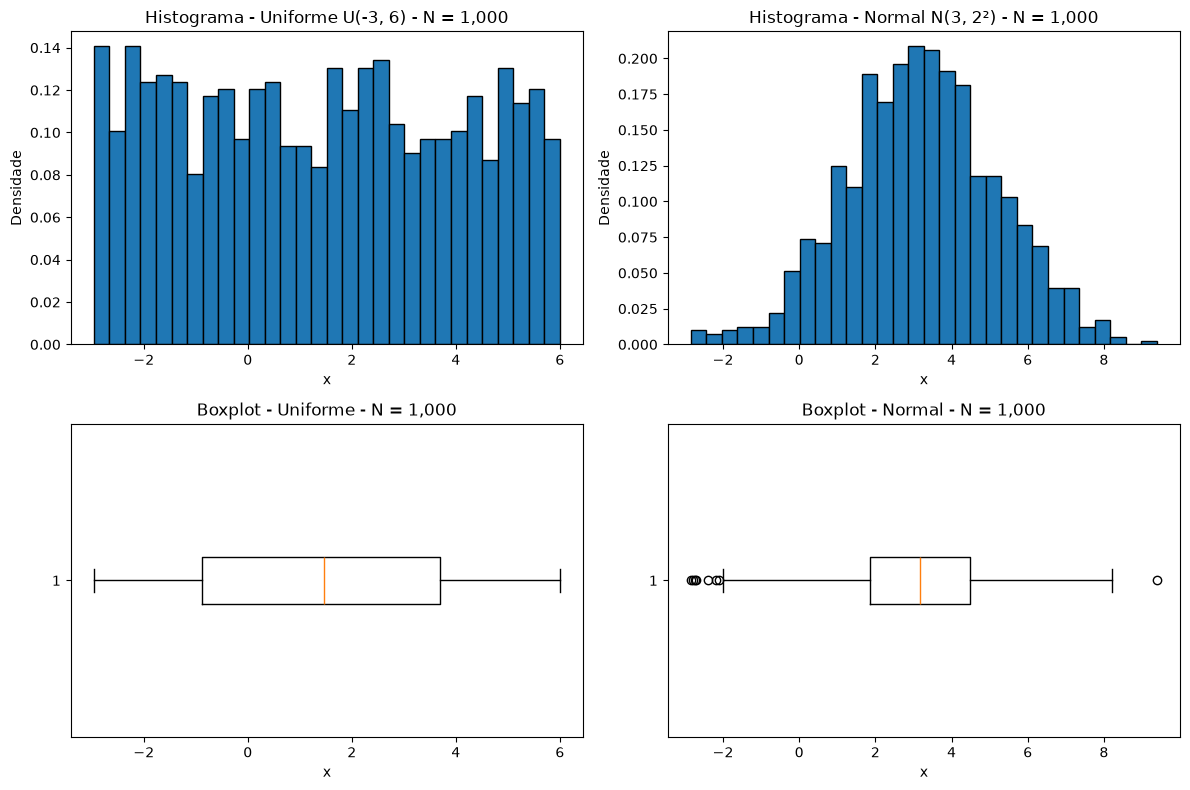

In [10]:

# ============================================================
# Questão 1. a e b
# ============================================================

# Números de amostras 1000
resultados, xU, xN = generate_random_variables(1000,  return_samples=True)


Distribuição Uniforme - N = 10000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    1.4582     1.50         0.0418             2.7893
1        Mediana    1.4148     1.50         0.0852             5.6808
2  Moda estimada    0.7488      NaN            NaN                NaN
3      Variância    6.6921     6.75         0.0579             0.8574
4     Assimetria    0.0249     0.00         0.0249                NaN
5        Curtose   -1.1859    -1.20         0.0141             1.1779

Distribuição Normal - N = 10000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    3.0223        3         0.0223             0.7443
1        Mediana    3.0275        3         0.0275             0.9164
2  Moda estimada    3.2766        3         0.2766             9.2212
3      Variância    3.9971        4         0.0029             0.0728
4     Assimetria   -0.0023        0         0.0023                NaN
5        Curtose    0.

/tmp/ipykernel_280699/3980338715.py:99: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(
/tmp/ipykernel_280699/3980338715.py:132: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


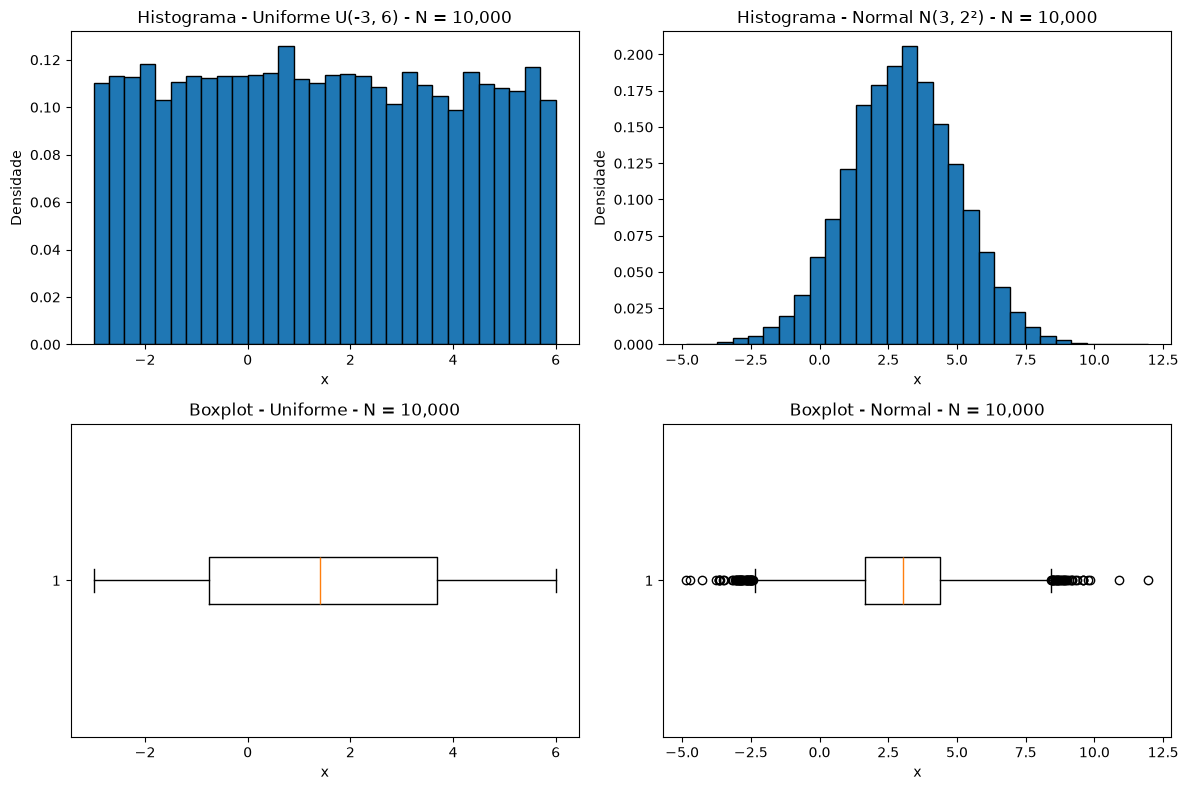


Distribuição Uniforme - N = 100000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    1.4892     1.50         0.0108             0.7173
1        Mediana    1.4967     1.50         0.0033             0.2203
2  Moda estimada   -0.1500      NaN            NaN                NaN
3      Variância    6.7360     6.75         0.0140             0.2075
4     Assimetria    0.0001     0.00         0.0001                NaN
5        Curtose   -1.2032    -1.20         0.0032             0.2701

Distribuição Normal - N = 100000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    3.0013        3         0.0013             0.0446
1        Mediana    3.0000        3         0.0000             0.0007
2  Moda estimada    2.8902        3         0.1098             3.6600
3      Variância    3.9891        4         0.0109             0.2735
4     Assimetria   -0.0043        0         0.0043                NaN
5        Curtose   -

/tmp/ipykernel_280699/3980338715.py:99: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(
/tmp/ipykernel_280699/3980338715.py:132: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


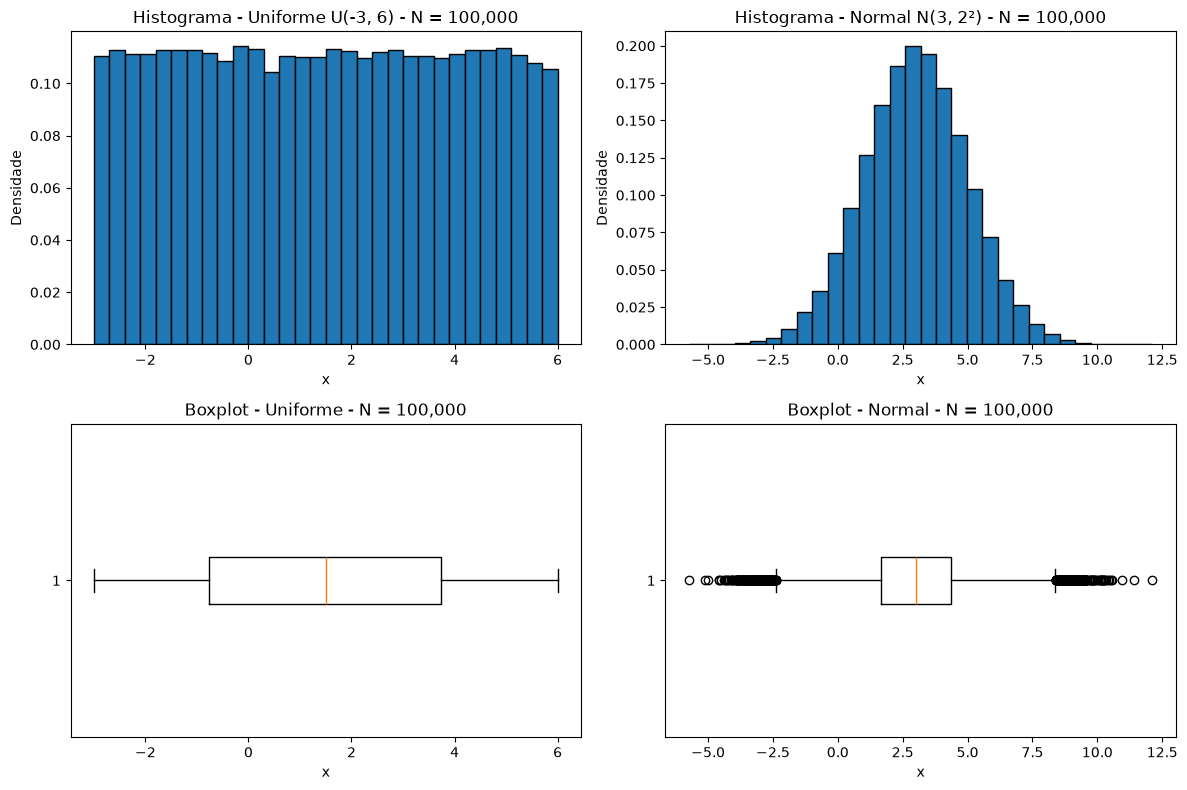


Resultados obtidos:
     N Distribuição  Média  Mediana  Moda estimada  Variância  Assimetria  Curtose
  1000     Uniforme 1.4123   1.4713        -2.8090     6.9129      0.0388  -1.2292
  1000       Normal 3.1978   3.1684         3.0679     3.9120     -0.0367  -0.0212
 10000     Uniforme 1.4582   1.4148         0.7488     6.6921      0.0249  -1.1859
 10000       Normal 3.0223   3.0275         3.2766     3.9971     -0.0023   0.0828
100000     Uniforme 1.4892   1.4967        -0.1500     6.7360      0.0001  -1.2032
100000       Normal 3.0013   3.0000         2.8902     3.9891     -0.0043  -0.0182


In [11]:
# ============================================================
# Questão 1. c e d
# ============================================================

# Números de amostras 10000
resultados10000 = generate_random_variables(10000)

# Números de amostras 10000
resultados100000 = generate_random_variables(100000)

# ============================================================
# Criando tabela com todos os resultados
# ============================================================

# Junta todos os resultados
resultados = (
    resultados
    + resultados10000
    + resultados100000
)

# Cria DataFrame
df_resultados = pd.DataFrame(resultados)

print("\nResultados obtidos:")
print(df_resultados.round(4).to_string(index=False))

Percebemos que, a partir dos resultados, à medida que o número de amostras aumenta, a média tende a se aproximar do valor teórico em ambas as distribuições.
Na distribuição uniforme, a média converge para o valor teórico de 1,5, enquanto, na distribuição normal, converge para 3. Esse comportamento é esperado,
uma vez que o aumento do número de amostras reduz o efeito das flutuações aleatórias.

## Questão 2

Utilizando as amostras `xU` e `xN` geradas no item 1 para `N = 10000`, vamos construir a variável `xSum = 2xN + xU³` e analisar seus resultados.

Estatísticas obtidas para xSum:
   N Distribuição  Média  Mediana  Moda estimada  Variância  Assimetria  Curtose
1000         xSum 6.8664    6.749         6.4177    16.0989     -0.0061  -0.0884


/tmp/ipykernel_280699/3405213317.py:40: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


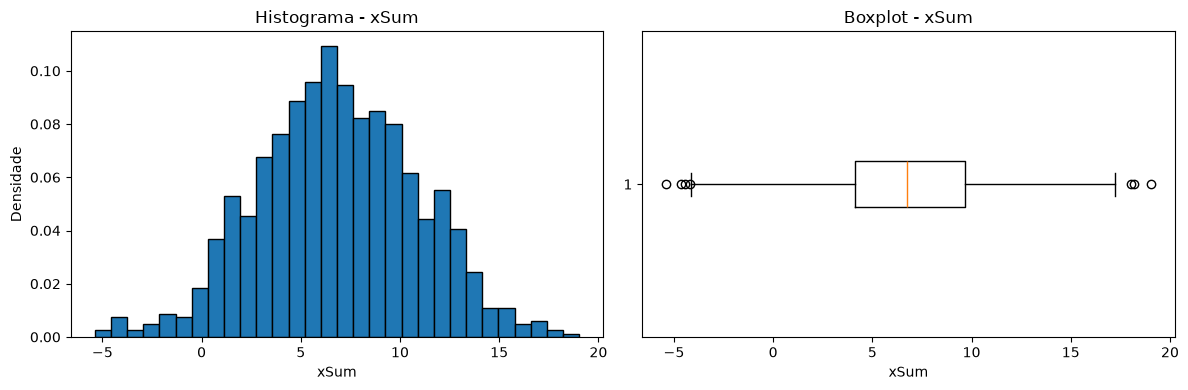

In [12]:
# ============================================================
# Questão 2. a
# ============================================================

# Reaproveitando as variáveis uniforme (xU) e normal (xN)
# criadas no item 1 para N = 10000
xSum = 2 * xN + xU / 3

# Estatísticas da variável xSum
estat_xSum = calcular_estatisticas(xSum)

df_xSum = pd.DataFrame([
    {
        "N": len(xSum),
        "Distribuição": "xSum",
        **estat_xSum
    }
])

print("Estatísticas obtidas para xSum:")
print(df_xSum.round(4).to_string(index=False))

# Histograma e boxplot de xSum
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    xSum,
    bins=30,
    edgecolor="black",
    density=True
)
axes[0].set_title("Histograma - xSum")
axes[0].set_xlabel("xSum")
axes[0].set_ylabel("Densidade")

axes[1].boxplot(
    xSum,
    vert=False
)
axes[1].set_title("Boxplot - xSum")
axes[1].set_xlabel("xSum")

plt.tight_layout()
plt.show()


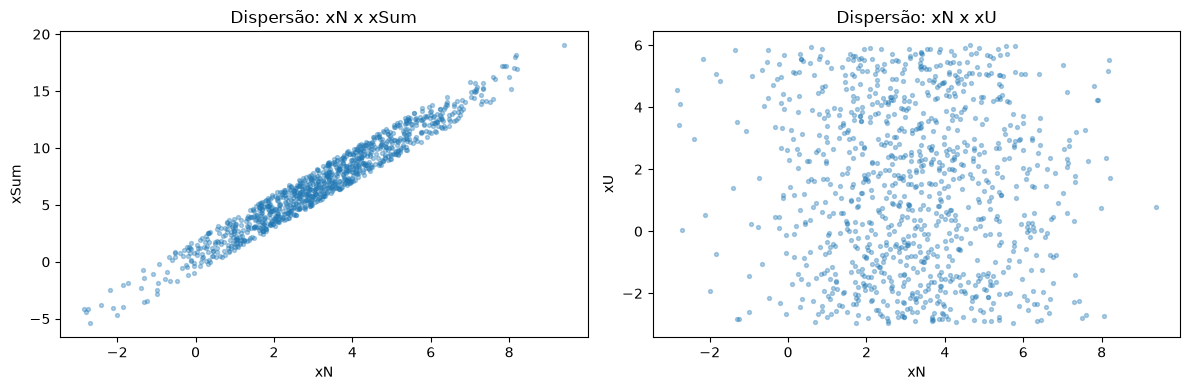

In [15]:
# ============================================================
# Questão 2. b
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Scatter-plot de XN x xSum
axes[0].scatter(
    xN,
    xSum,
    alpha=0.35,
    s=8
)
axes[0].set_title("Dispersão: xN x xSum")
axes[0].set_xlabel("xN")
axes[0].set_ylabel("xSum")

# Scatter-plot de XN x xU
axes[1].scatter(
    xN,
    xU,
    alpha=0.35,
    s=8
)
axes[1].set_title("Dispersão: xN x xU")
axes[1].set_xlabel("xN")
axes[1].set_ylabel("xU")

plt.tight_layout()
plt.show()


In [16]:

# ============================================================
# Questão 2. c
# ============================================================

# Coeficientes de correlação de Pearson
corr_xN_xSum = np.corrcoef(xN, xSum)[0, 1]
corr_xN_xU = np.corrcoef(xN, xU)[0, 1]

df_correlacoes = pd.DataFrame({
    "Variáveis": [
        "xN e xSum",
        "xN e xU"
    ],
    "Correlação": [
        corr_xN_xSum,
        corr_xN_xU
    ]
})

print("Coeficientes de correlação:")
print(df_correlacoes.round(4).to_string(index=False))


Coeficientes de correlação:
Variáveis  Correlação
xN e xSum      0.9759
  xN e xU     -0.0457


### Questão 2. d

A variável `xSum` apresentou valores de média, mediana e moda relativamente próximos, indicando uma distribuição relativamente concentrada. A variância entretanto foi maior do que a variância da normal, pois `xSum` combina duas variáveis aleatórias e, recebe o termo `2xN`, que amplia a variabilidade da variável normal.

Nos gráficos de dispersão, observa-se que `xN x xSum` apresenta uma tendência linear bem definida. Isso ocorre porque `xSum = 2xN + xU / 3`, ou seja, `xSum` depende diretamente de `xN`. Essa relação também aparece no coeficiente de correlação, que foi `0.9759`, indicando uma correlação positiva muito forte entre `xN` e `xSum`.

Já no gráfico `xN x xU`, os pontos aparecem mais espalhados. O coeficiente de correlação entre `xN` e `xU` foi muito próximo de zero, indicando ausência de correlação linear relevante. Oque faz sentido uma vez que `xU` e `xN` são variaveis independentes.